# 대한민국 법률 서비스 접근성 불균형 분석
## 지역별 종합 법률 접근성 지수(LLAI) — 분석 정리 노트북

서강대 26-1 빅데이터컴퓨팅(BDS3010) · 20210717 김찬우

이 노트북은 `src/` 모듈(수집·정제·지수·모델 **엔진**)을 불러와 전체 분석 흐름을 한눈에 정리한다.  
데이터 처리 로직은 `src/`에 두고, 노트북은 **결과를 재현·설명·해석**한다.

```
src/collect/scrape_bar.py   변협 회원현황 스크랩
src/prepare/load_kosis.py   KOSIS 인구·GRDP·수급자 정제
src/prepare/load_klac.py    공단 법률구조(A3) 정제
src/prepare/load_court.py   사법연감 법원사건(A2) 정제
src/prepare/build_panel.py  13권역·10도단위 패널 조립
src/index/compute_llai.py   A1~A3 -> 정규화 -> 가중치 3종 -> LLAI
src/model/cluster.py        K-means 클러스터링
```

## 1. 배경 · 연구 목적

로스쿨 도입(2009) 이후 변호사 수가 4만 명을 넘어섰지만, 법률 서비스 자원의 **지역 편중**은 심화되고 있다는 지적이 있다. 본 프로젝트는 지역별 법률 접근성을 단일 종합지수(**LLAI**)로 정량화하고 격차의 구조를 규명한다.

**3개 차원**

| 지표 | 정의 | 방향 |
|---|---|---|
| A1 변호사 접근성 | 인구 10만 명당 개업변호사 수 | 높을수록 좋음 |
| A2 사건 부담 | 변호사 1인당 법원 본안사건 수 | 낮을수록 좋음 |
| A3 취약계층 접근성 | 법률구조 건수 / 저소득층 인구 | 높을수록 좋음 |

**가설** — H1: 수도권 변호사 1인당 인구 < 비수도권 / H2: 변호사 적을수록 사건부담↑ / H3: 소득 낮을수록 법률구조 수요↑·자원↓ / H4: 로스쿨 이후에도 격차 미축소

## 2. 데이터 출처 · 분석 단위

| 차원 | 출처 | 단위 | 기간 |
|---|---|---|---|
| A1 변호사 | 대한변호사협회 회원현황(스냅샷) | 14 지방회 | 현재 |
| A2 법원사건 | 대법원 **사법연감 2024**(본안사건) | 법원관내 | 2024 |
| A3 법률구조 | 대한법률구조공단(민사, 지역별) | 10 도단위 | 2012~2025 |
| 인구·저소득층·GRDP | 통계청 KOSIS | 17 시도 | 2008~2025 |

### 분석 단위가 두 가지인 이유
각 출처의 지역 해상도가 다르다. 변협은 14지방회(부산·인천·울산 분리), 공단은 10도단위(광역시를 인접 도에 통합)다. 그래서 **두 단위를 병행**한다.

- **region13** — 변협 기준 13권역. 부산·인천·울산 분리 유지. A3는 인구비 근사배분.
- **region10** — 공단 기준 10도단위. 모든 지표 공통 해상도(가장 정합적).

단일 기준표: `region_mapping.csv`.  
**A2는 '본안사건'**(민사본안+형사공판+가사+행정 제1심) 사용 — 비송(등기·공탁 980만건) 제외.

> 검증: 법원관내 인구 합 = region10 KOSIS 인구와 정확히 일치(부산+울산+창원관내=경남권 759만). 본안사건 합 1,106,526 = 사법연감 전국 본안과 일치.

In [1]:
# --- 환경 설정 ---
import sys
from pathlib import Path
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

import config
from index.compute_llai import compute_llai, NEED, DIRECTED
from model.cluster import choose_k
from sklearn.cluster import KMeans

pd.set_option('display.unicode.east_asian_width', True)
print('프로젝트 루트:', ROOT)
print('LLAI 입력 컬럼:', NEED)

프로젝트 루트: d:\01_sogang-univ\04_26-1학기\06_빅데이터 컴퓨팅\프로젝트
LLAI 입력 컬럼: ['practicing', 'population', 'total_cases', 'low_income_pop', 'aid_cases']


## 3. 데이터 수집·정제 파이프라인

각 `src` 스크립트가 원본을 tidy 형태로 변환한다. (재생성: 터미널에서 `python src/prepare/load_kosis.py` 등) 아래는 정제 산출물 미리보기.

In [2]:
# 변호사(A1) — 변협 스냅샷 -> 13권역
bar = pd.read_csv(ROOT / 'data/raw/bar/bar_region13.csv')
display(bar)

,asof,region13_name,practicing,associate,total
0,2026-06-04,서울,24572,5160,29732
1,2026-06-04,경기,1883,380,2263
2,2026-06-04,인천,748,144,892
3,2026-06-04,강원,192,40,232
4,2026-06-04,충북,232,56,288
5,2026-06-04,대전권,813,172,985
6,2026-06-04,대구권,847,130,977
7,2026-06-04,부산,1210,213,1423
8,2026-06-04,울산,252,21,273
9,2026-06-04,경남,420,75,495


In [3]:
# KOSIS 정제 결과 (인구 / 1인당 GRDP / 기초생활수급자)
for name in ['kosis_population', 'kosis_grdp', 'kosis_basic']:
    d = pd.read_csv(ROOT / f'data/interim/{name}.csv')
    print(f'[{name}] {len(d)}행  {d["year"].min()}~{d["year"].max()}')
    display(d.head(3))

[kosis_population] 302행  2008~2025


,sido_name,year,population
0,강원특별자치도,2008,1508575.0
1,강원특별자치도,2009,1512870.0
2,강원특별자치도,2010,1529818.0


[kosis_grdp] 250행  2008~2022


,sido_name,year,grdp_per_capita
0,강원도,2008,19593.0
1,강원도,2009,20345.0
2,강원도,2010,21312.0


[kosis_basic] 269행  2009~2024


,sido_name,year,low_income_pop
0,강원특별자치도,2009,63753.0
1,강원특별자치도,2010,62850.0
2,강원특별자치도,2011,58949.0


In [4]:
# 법률구조(A3, region10) / 법원사건(A2, region13)
klac = pd.read_csv(ROOT / 'data/interim/klac_legalaid.csv')
court = pd.read_csv(ROOT / 'data/interim/court_cases.csv')
print('A3 법률구조(민사, 연합산) 최신연도:'); display(klac[klac.year == klac.year.max()])
print('A2 법원 본안사건(2024):'); display(court)

A3 법률구조(민사, 연합산) 최신연도:


,region10,year,aid_cases
13,강원,2025,2968
27,경기,2025,37480
41,경남권,2025,24439
55,경북권,2025,13482
69,서울,2025,23343
83,전남권,2025,10099
97,전북,2025,5747
111,제주,2025,3093
125,충남권,2025,7039
139,충북,2025,2948


A2 법원 본안사건(2024):


,region13,year,total_cases,civil_main,criminal_trial
0,서울,2024,398500.0,340346.0,41876.0
1,경기,2024,200902.0,138246.0,48930.0
2,인천,2024,81341.0,54582.0,22003.0
3,강원,2024,23226.0,13904.0,7805.0
4,충북,2024,24972.0,15708.0,7690.0
5,대전권,2024,67013.0,43280.0,19380.0
6,대구권,2024,78234.0,49661.0,23805.0
7,부산,2024,64768.0,43434.0,18049.0
8,울산,2024,22465.0,13675.0,6967.0
9,경남,2024,43385.0,27262.0,13138.0


## 4. 통합 패널 (region10 / region13)

`build_panel.py`가 5개 원천을 권역×연도 패널로 합친다. 변호사 스냅샷이 있는 **기준연도(2024)** 단면에서 LLAI 입력 5종이 모두 채워진다.

In [5]:
def cross_section(unit):
    """패널에서 LLAI 입력이 모두 존재하는 최신 연도 단면을 반환."""
    p = pd.read_csv(ROOT / f'data/processed/panel_{unit}.csv')
    ref = int(p.dropna(subset=NEED)['year'].max())
    return p[p['year'] == ref].dropna(subset=NEED).copy(), ref

cs10, ref10 = cross_section('region10')
print(f'region10 기준연도 {ref10} · {len(cs10)}개 권역')
display(cs10[['region'] + NEED])

region10 기준연도 2024 · 10개 권역


,region,practicing,population,total_cases,low_income_pop,aid_cases
160,서울,24572.0,9331828.0,398500.0,434287.0,22072.0
161,경기,2631.0,16715695.0,282243.0,660736.0,31645.0
162,강원,192.0,1517766.0,23226.0,84290.0,3020.0
163,충북,232.0,1591177.0,24972.0,79187.0,2891.0
164,충남권,813.0,3966416.0,67013.0,178605.0,6686.0
165,경북권,847.0,4895013.0,78234.0,306063.0,12661.0
166,경남권,1882.0,7593027.0,130618.0,461912.0,22035.0
167,전북,321.0,1738690.0,27523.0,130243.0,4935.0
168,전남권,629.0,3197241.0,59419.0,203162.0,8742.0
169,제주,154.0,670368.0,14778.0,35293.0,2495.0


## 5. LLAI 산출 — 가중치 3종 비교

A1~A3를 Min-Max 정규화(A2는 역방향) 후 **균등 / 엔트로피 / PCA** 세 가중치로 산출한다.  
지표가 3개뿐이라 단일 가중치는 불안정하므로 **강건성** 확인을 위해 병기한다.

In [6]:
def llai_table(unit):
    cs, ref = cross_section(unit)
    df, w = compute_llai(cs)
    df = df.sort_values('LLAI', ascending=False)
    print(f'=== {unit} (기준연도 {ref}) ===')
    print('가중치(행=방식):'); display(w.round(3))
    cols = ['region', 'A1', 'A2', 'A3', 'LLAI_equal', 'LLAI_entropy', 'LLAI_pca', 'LLAI']
    display(df[cols].round(2))
    return df

llai10 = llai_table('region10')

=== region10 (기준연도 2024) ===
가중치(행=방식):


,A1(변호사),"A2(사건부담,역)",A3(취약계층)
equal,0.333,0.333,0.333
entropy,0.639,0.131,0.229
pca,0.405,0.406,0.189


,region,A1,A2,A3,LLAI_equal,LLAI_entropy,LLAI_pca,LLAI
160,서울,263.31,16.22,0.05,81.00,86.93,89.23,86.93
169,제주,22.97,95.96,0.07,42.66,28.71,30.27,28.71
166,경남권,24.79,69.40,0.05,29.38,17.38,28.39,17.38
161,경기,15.74,107.28,0.05,16.30,10.44,12.35,10.44
168,전남권,19.67,94.47,0.04,16.25,9.85,15.31,9.85
165,경북권,17.30,92.37,0.04,15.02,8.42,14.84,8.42
164,충남권,20.50,82.43,0.04,14.84,7.89,17.08,7.89
167,전북,18.46,85.74,0.04,13.95,7.26,15.72,7.26
163,충북,14.58,107.64,0.04,5.15,2.61,5.85,2.61
162,강원,12.65,120.97,0.04,0.00,0.00,0.00,0.00


In [7]:
llai13 = llai_table('region13')

=== region13 (기준연도 2024) ===
가중치(행=방식):


,A1(변호사),"A2(사건부담,역)",A3(취약계층)
equal,0.333,0.333,0.333
entropy,0.687,0.142,0.171
pca,0.445,0.445,0.110


,region,A1,A2,A3,LLAI_equal,LLAI_entropy,LLAI_pca,LLAI
208,서울,263.31,16.22,0.05,82.73,91.13,94.28,91.13
216,울산,22.95,89.15,0.07,44.83,24.24,26.38,24.24
220,제주,22.97,95.96,0.07,42.62,23.31,23.47,23.31
215,부산,37.04,53.53,0.04,31.16,19.11,35.10,19.11
209,경기,13.75,106.69,0.05,23.16,11.72,12.37,11.72
217,경남,13.01,103.30,0.05,23.22,11.50,13.38,11.50
218,광주권,19.67,94.47,0.04,18.67,10.29,15.58,10.29
213,대전권,20.50,82.43,0.04,17.76,9.65,19.23,9.65
214,대구권,17.30,92.37,0.04,17.59,9.18,15.57,9.18
219,전북,18.46,85.74,0.04,16.83,8.84,17.60,8.84


### 해석
- **서울이 압도적 1위** (LLAI 87~91). 변호사 263명/10만명으로 2위권(13~37)과 격차 극단적.
- 가중치 방식별로 A2 비중이 크게 갈린다(PCA ~0.4 vs 엔트로피 ~0.13) → **가중치 선택이 순위에 영향**.
- 엔트로피 가중치가 A1에 0.64~0.69 부여 → **변호사 분포 불균등이 격차를 지배**(H1 지지).

## 6. 클러스터링 — 접근성 유형별 권역 그룹

방향보정·정규화 지표(A1n, 1−A2n, A3n)로 K-means. 최적 K는 Elbow+Silhouette로 결정.

In [8]:
def cluster_table(df, unit):
    cur = df.copy()
    X = cur[DIRECTED].to_numpy()
    diag = choose_k(X)
    best_k = int(diag.loc[diag['silhouette'].idxmax(), 'k'])
    km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X)
    cur['cluster'] = km.labels_
    order = cur.groupby('cluster')['LLAI'].mean().sort_values(ascending=False)
    rank = {c: i for i, c in enumerate(order.index)}
    cur['cluster_rank'] = cur['cluster'].map(rank)
    print(f'=== {unit} · 최적 K={best_k} ===')
    display(diag.round(3))
    out = cur.sort_values(['cluster_rank', 'LLAI'], ascending=[True, False])
    display(out[['region', 'A1', 'A2', 'A3', 'LLAI', 'cluster_rank']].round(2))
    return out

_ = cluster_table(llai10, 'region10')

c:\Users\Allen\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 지정된 파일을 찾을 수 없습니다
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Allen\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Allen\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Allen\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


=== region10 · 최적 K=2 ===


c:\Users\Allen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,k,inertia,silhouette
0,2,0.958,0.618
1,3,0.311,0.540
2,4,0.169,0.306
3,5,0.102,0.295
4,6,0.035,0.304


,region,A1,A2,A3,LLAI,cluster_rank
160,서울,263.31,16.22,0.05,86.93,0
169,제주,22.97,95.96,0.07,28.71,1
166,경남권,24.79,69.40,0.05,17.38,1
161,경기,15.74,107.28,0.05,10.44,1
168,전남권,19.67,94.47,0.04,9.85,1
165,경북권,17.30,92.37,0.04,8.42,1
164,충남권,20.50,82.43,0.04,7.89,1
167,전북,18.46,85.74,0.04,7.26,1
163,충북,14.58,107.64,0.04,2.61,1
162,강원,12.65,120.97,0.04,0.00,1


In [9]:
_ = cluster_table(llai13, 'region13')

c:\Users\Allen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Allen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Allen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Allen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

=== region13 · 최적 K=2 ===


c:\Users\Allen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,k,inertia,silhouette
0,2,1.597,0.586
1,3,0.560,0.496
2,4,0.334,0.509
3,5,0.140,0.558
4,6,0.045,0.569


,region,A1,A2,A3,LLAI,cluster_rank
208,서울,263.31,16.22,0.05,91.13,0
216,울산,22.95,89.15,0.07,24.24,1
220,제주,22.97,95.96,0.07,23.31,1
215,부산,37.04,53.53,0.04,19.11,1
209,경기,13.75,106.69,0.05,11.72,1
217,경남,13.01,103.30,0.05,11.50,1
218,광주권,19.67,94.47,0.04,10.29,1
213,대전권,20.50,82.43,0.04,9.65,1
214,대구권,17.30,92.37,0.04,9.18,1
219,전북,18.46,85.74,0.04,8.84,1


## 7. 주요 발견

1. **서울 일극 집중** — A1에서 서울이 극단적 이상치(변호사 263명/10만명). 클러스터링에서 단독 그룹 분리(K=2).
2. **'수도권 우위'는 사실상 서울 단독 현상** — 인구가 큰 **인천·경기는 중하위권**(특히 인천은 사건부담 A2가 높아 최하위권, LLAI 4.97). 인구가 적은 울산·제주가 오히려 1인당 접근성 상위. → 서울 제외 비교는 `04_서울제외_비교` 참고.
3. **변호사 수 ↔ 사건부담 강한 음의 상관(H2)** — 변호사가 부족한 권역일수록 변호사 1인당 사건부담↑.
4. **A3 변별력 약함** — 값이 0.03~0.07로 좁게 분포. 법률구조가 수요를 충분히 반영 못할 가능성(H3).
5. **가중치 민감성** — LLAI 순위가 가중치 방식에 따라 일부 변동 → 단일 지수 해석 시 주의.

## 8. 남은 작업

- [ ] **시각화**: 코로플레스 지도(folium), LLAI 막대/산점도, 클러스터 지도
- [ ] **회귀분석**: 구조요인(1인당 GRDP·고령화율·인구밀도) → LLAI (statsmodels)
- [ ] **가설 검정**: H1~H4 정량 검정
- [ ] **보고서·발표자료**

> 시각화·회귀에는 `pip install matplotlib seaborn folium geopandas statsmodels` 필요.

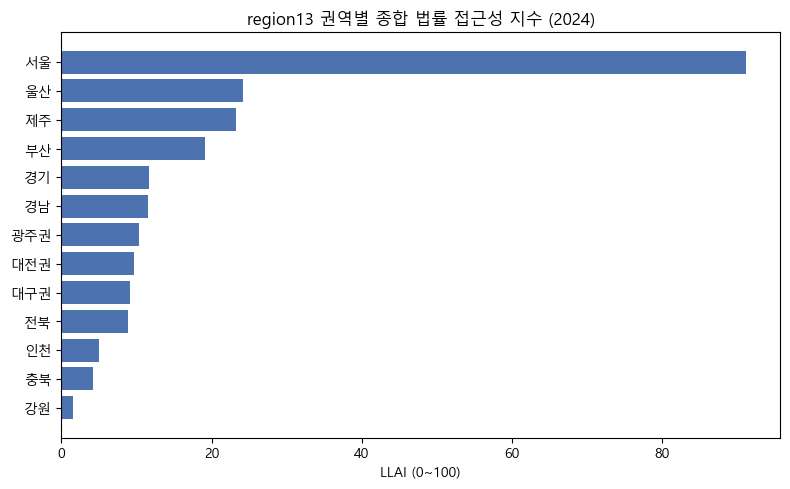

In [10]:
# (선택) 시각화 예시 — matplotlib 설치 후 실행
# !pip install matplotlib
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

d = llai13.sort_values('LLAI')
plt.figure(figsize=(8, 5))
plt.barh(d['region'], d['LLAI'], color='#4C72B0')
plt.xlabel('LLAI (0~100)')
plt.title('region13 권역별 종합 법률 접근성 지수 (2024)')
plt.tight_layout(); plt.show()